In [2]:
import pandas as pd
from scipy.stats import levene
from model_comparison import (calc_classification_metrics, 
                              make_ci_plot_grid, 
                              make_mcs_plot_grid, 
                              make_normality_diagnostic,
                              make_boxplots_parametric, 
                              make_scatterplot,
                              rm_tukey_hsd, 
                              make_curve_plots)
import pickle

# Custom Polaris

## Load data

In [3]:
from pyparsing import col


tm60_cv = pd.read_csv(r'M:\ML_scripts\polaris\tm60-trials-data\best_trial_fold_metrics.csv').drop(columns=['Unnamed: 0'])
cm60_cv = pd.read_csv(r'M:\ML_scripts\polaris\cm60-trials-data\best_trial_fold_metrics.csv').drop(columns=['Unnamed: 0'])

tm65_cv = pd.read_csv(r'M:\ML_scripts\polaris\tm65-trials-data\best_trial_fold_metrics.csv').drop(columns=['Unnamed: 0'])
cm65_cv = pd.read_csv(r'M:\ML_scripts\polaris\cm65-trials-data\best_trial_fold_metrics.csv').drop(columns=['Unnamed: 0'])

metric_df = pd.concat([tm60_cv, cm60_cv, tm65_cv, cm65_cv], axis=0)

metric_df['cv_cycle'] = metric_df.index
metric_df['split'] = 'stratified'

metric_df = metric_df.rename(columns={'model': 'method'})

metric_list = list(metric_df.columns[1:4])

x60 = metric_df[metric_df['method'].str.contains('60')]
x65 = metric_df[metric_df['method'].str.contains('65')]

TM = metric_df[metric_df['method'].str.contains('tm')]
CM = metric_df[metric_df['method'].str.contains('cm')]


# NS = pd.read_csv(r'M:\ML_scripts\polaris\ns-combined-best-fold-metrics.csv').drop(columns=['Unnamed: 0'])

# ns_metric_df = NS

# ns_metric_df['cv_cycle'] = ns_metric_df.index
# ns_metric_df['split'] = 'stratified'
# ns_metric_df = ns_metric_df.rename(columns={'model': 'method'})

# cv data from modified models

In [4]:
tm60_ecfpco_r3_1024 = pd.read_csv(r'M:\ML_scripts\polaris-models\tm60_ecfp-co_1024\cv_trials.csv').drop(columns=['Unnamed: 0'])
tm60_ecfpco_r3_2048 = pd.read_csv(r'M:\ML_scripts\polaris\tm60-trials-data\best_trial_fold_metrics.csv').drop(columns=['Unnamed: 0'])
tm60_ecfpco_r4_1024 = pd.read_csv(r'M:\ML_scripts\polaris-models\tm60_ecfp-co_r4_1024\cv_trials.csv').drop(columns=['Unnamed: 0'])
tm60_ecfpco_r4_2048 = pd.read_csv(r'M:\ML_scripts\polaris-models\tm60_ecfp-co_r4_2048\cv_trials.csv').drop(columns=['Unnamed: 0'])
tm60_ecfpco_r2_1024 = pd.read_csv(r'M:\ML_scripts\polaris-models\tm60_ecfp-co_r2_1024\cv_trials.csv').drop(columns=['Unnamed: 0'])
tm60_ecfpco_r2_2048 = pd.read_csv(r'M:\ML_scripts\polaris-models\tm60_ecfp-co_r2_2048\cv_trials.csv').drop(columns=['Unnamed: 0'])

tm60_mods_df = pd.concat([tm60_ecfpco_r3_1024, tm60_ecfpco_r3_2048,
                          tm60_ecfpco_r4_1024, tm60_ecfpco_r4_2048,
                          tm60_ecfpco_r2_1024, tm60_ecfpco_r2_2048], axis=0)

tm60_mods_df['cv_cycle'] = tm60_mods_df.index
tm60_mods_df['split'] = 'stratified'

tm60_mods_df = tm60_mods_df.rename(columns={'model': 'method'})

metric_list = list(tm60_mods_df.columns[1:4])

In [16]:
tm60_mods_df.head()

,method,roc_auc,mcc,auc_pr_cal,cv_cycle,split
0,tm60_RF_ECFP-co_1024,0.783745,0.392001,0.272050,0,stratified
1,tm60_RF_ECFP-co_1024,0.718433,0.297161,0.236891,1,stratified
2,tm60_RF_ECFP-co_1024,0.751814,0.353819,0.312845,2,stratified
3,tm60_RF_ECFP-co_1024,0.759434,0.352343,0.225552,3,stratified
4,tm60_RF_ECFP-co_1024,0.783745,0.467151,0.531747,4,stratified


## homogeneity of variances assumption

In [17]:
for metric in metric_list:
    groups = tm60_mods_df.groupby('method')[metric].apply(list)
    stat, pvalue = levene(*groups)
    print(f'Levene test for {metric}: p-value = {pvalue}')

variances_by_model = tm60_mods_df.groupby('method')[metric_list].var()
max_fold_diff = variances_by_model.max() / variances_by_model.min()
print('\n',max_fold_diff)

Levene test for roc_auc: p-value = 0.9977364100562447
Levene test for mcc: p-value = 0.9876515544352674
Levene test for auc_pr_cal: p-value = 0.9760949937865034

 roc_auc       1.625739
mcc           1.785334
auc_pr_cal    1.764389
dtype: float64


## the normality assumption

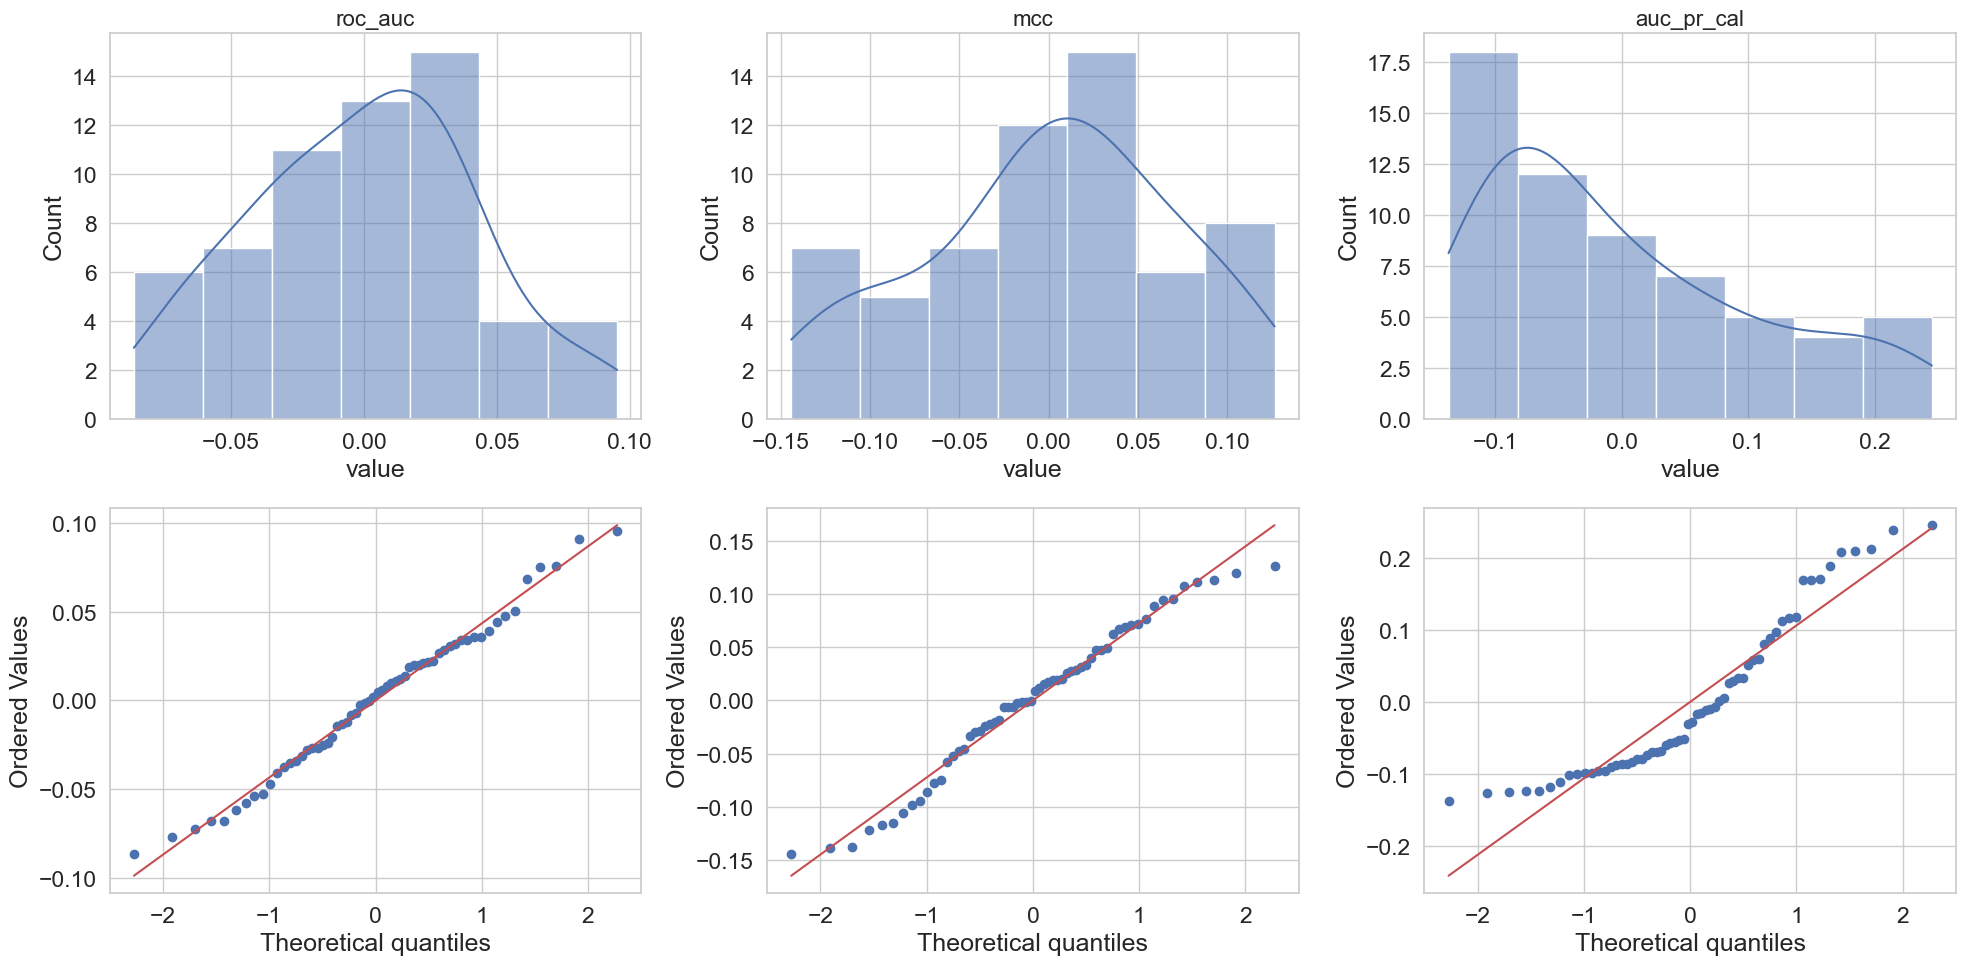

In [18]:
make_normality_diagnostic(tm60_mods_df.copy(), metric_list)

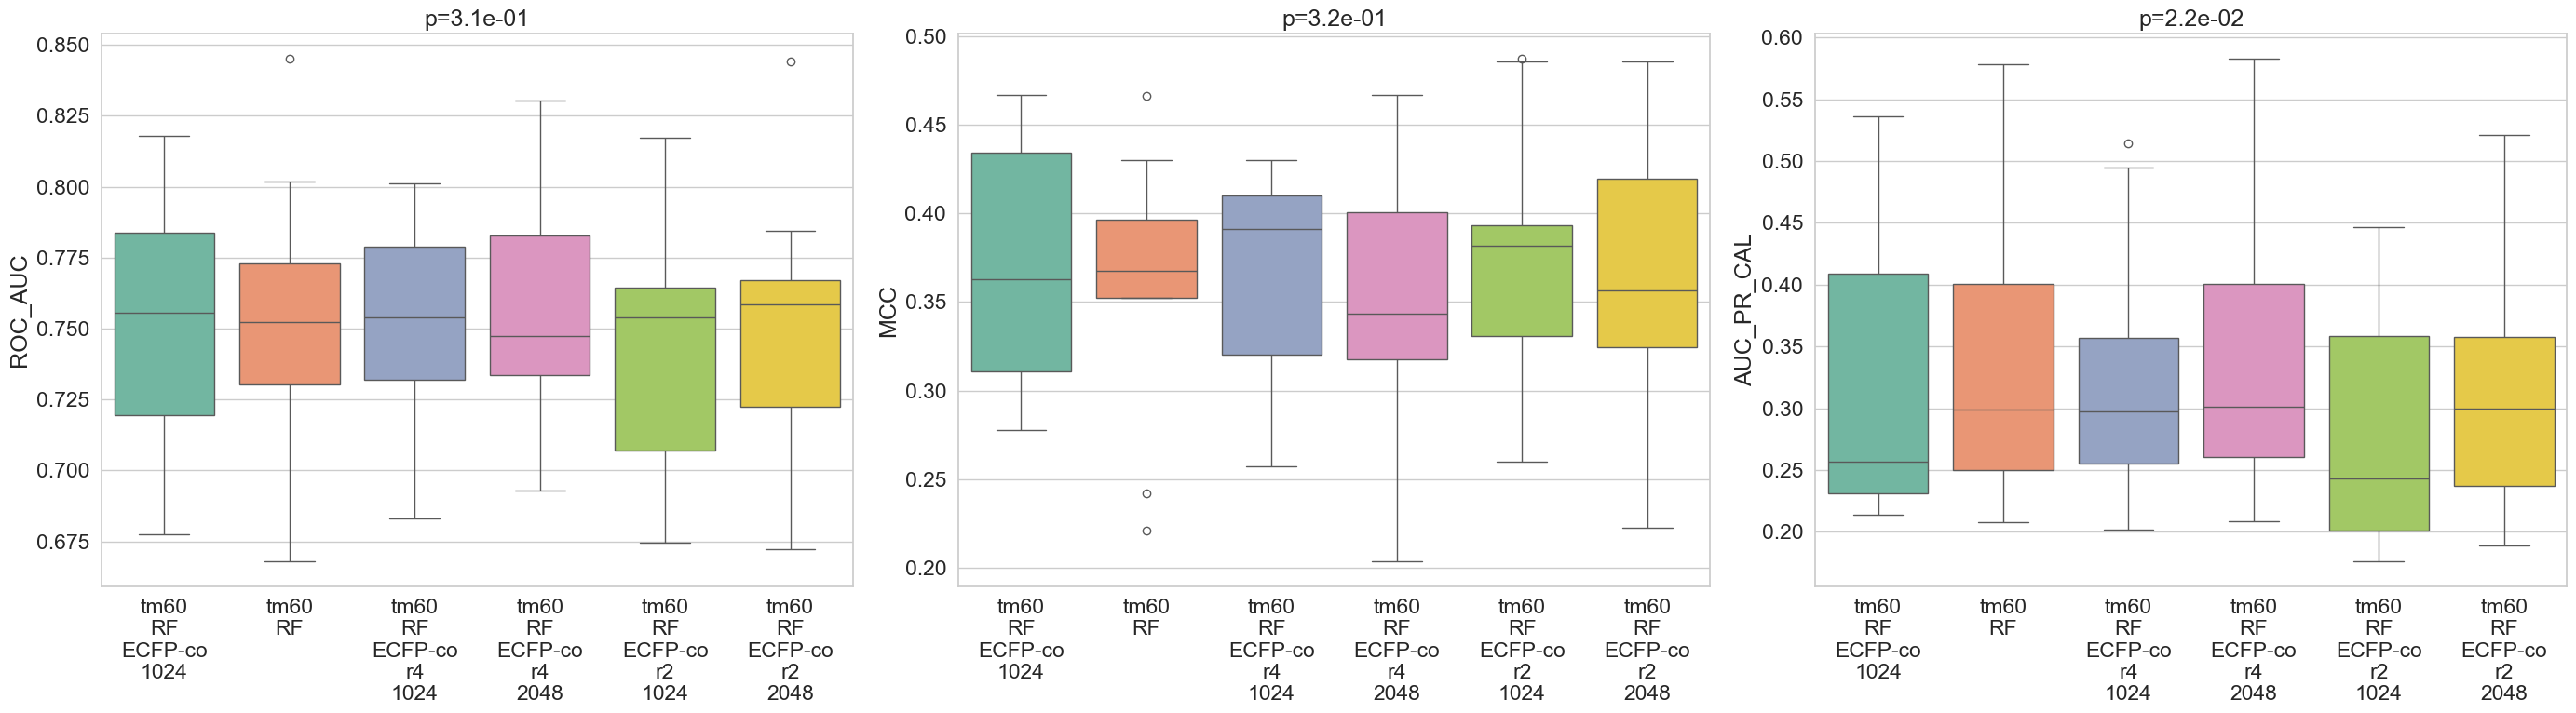

In [19]:
make_boxplots_parametric(tm60_mods_df, metric_list)

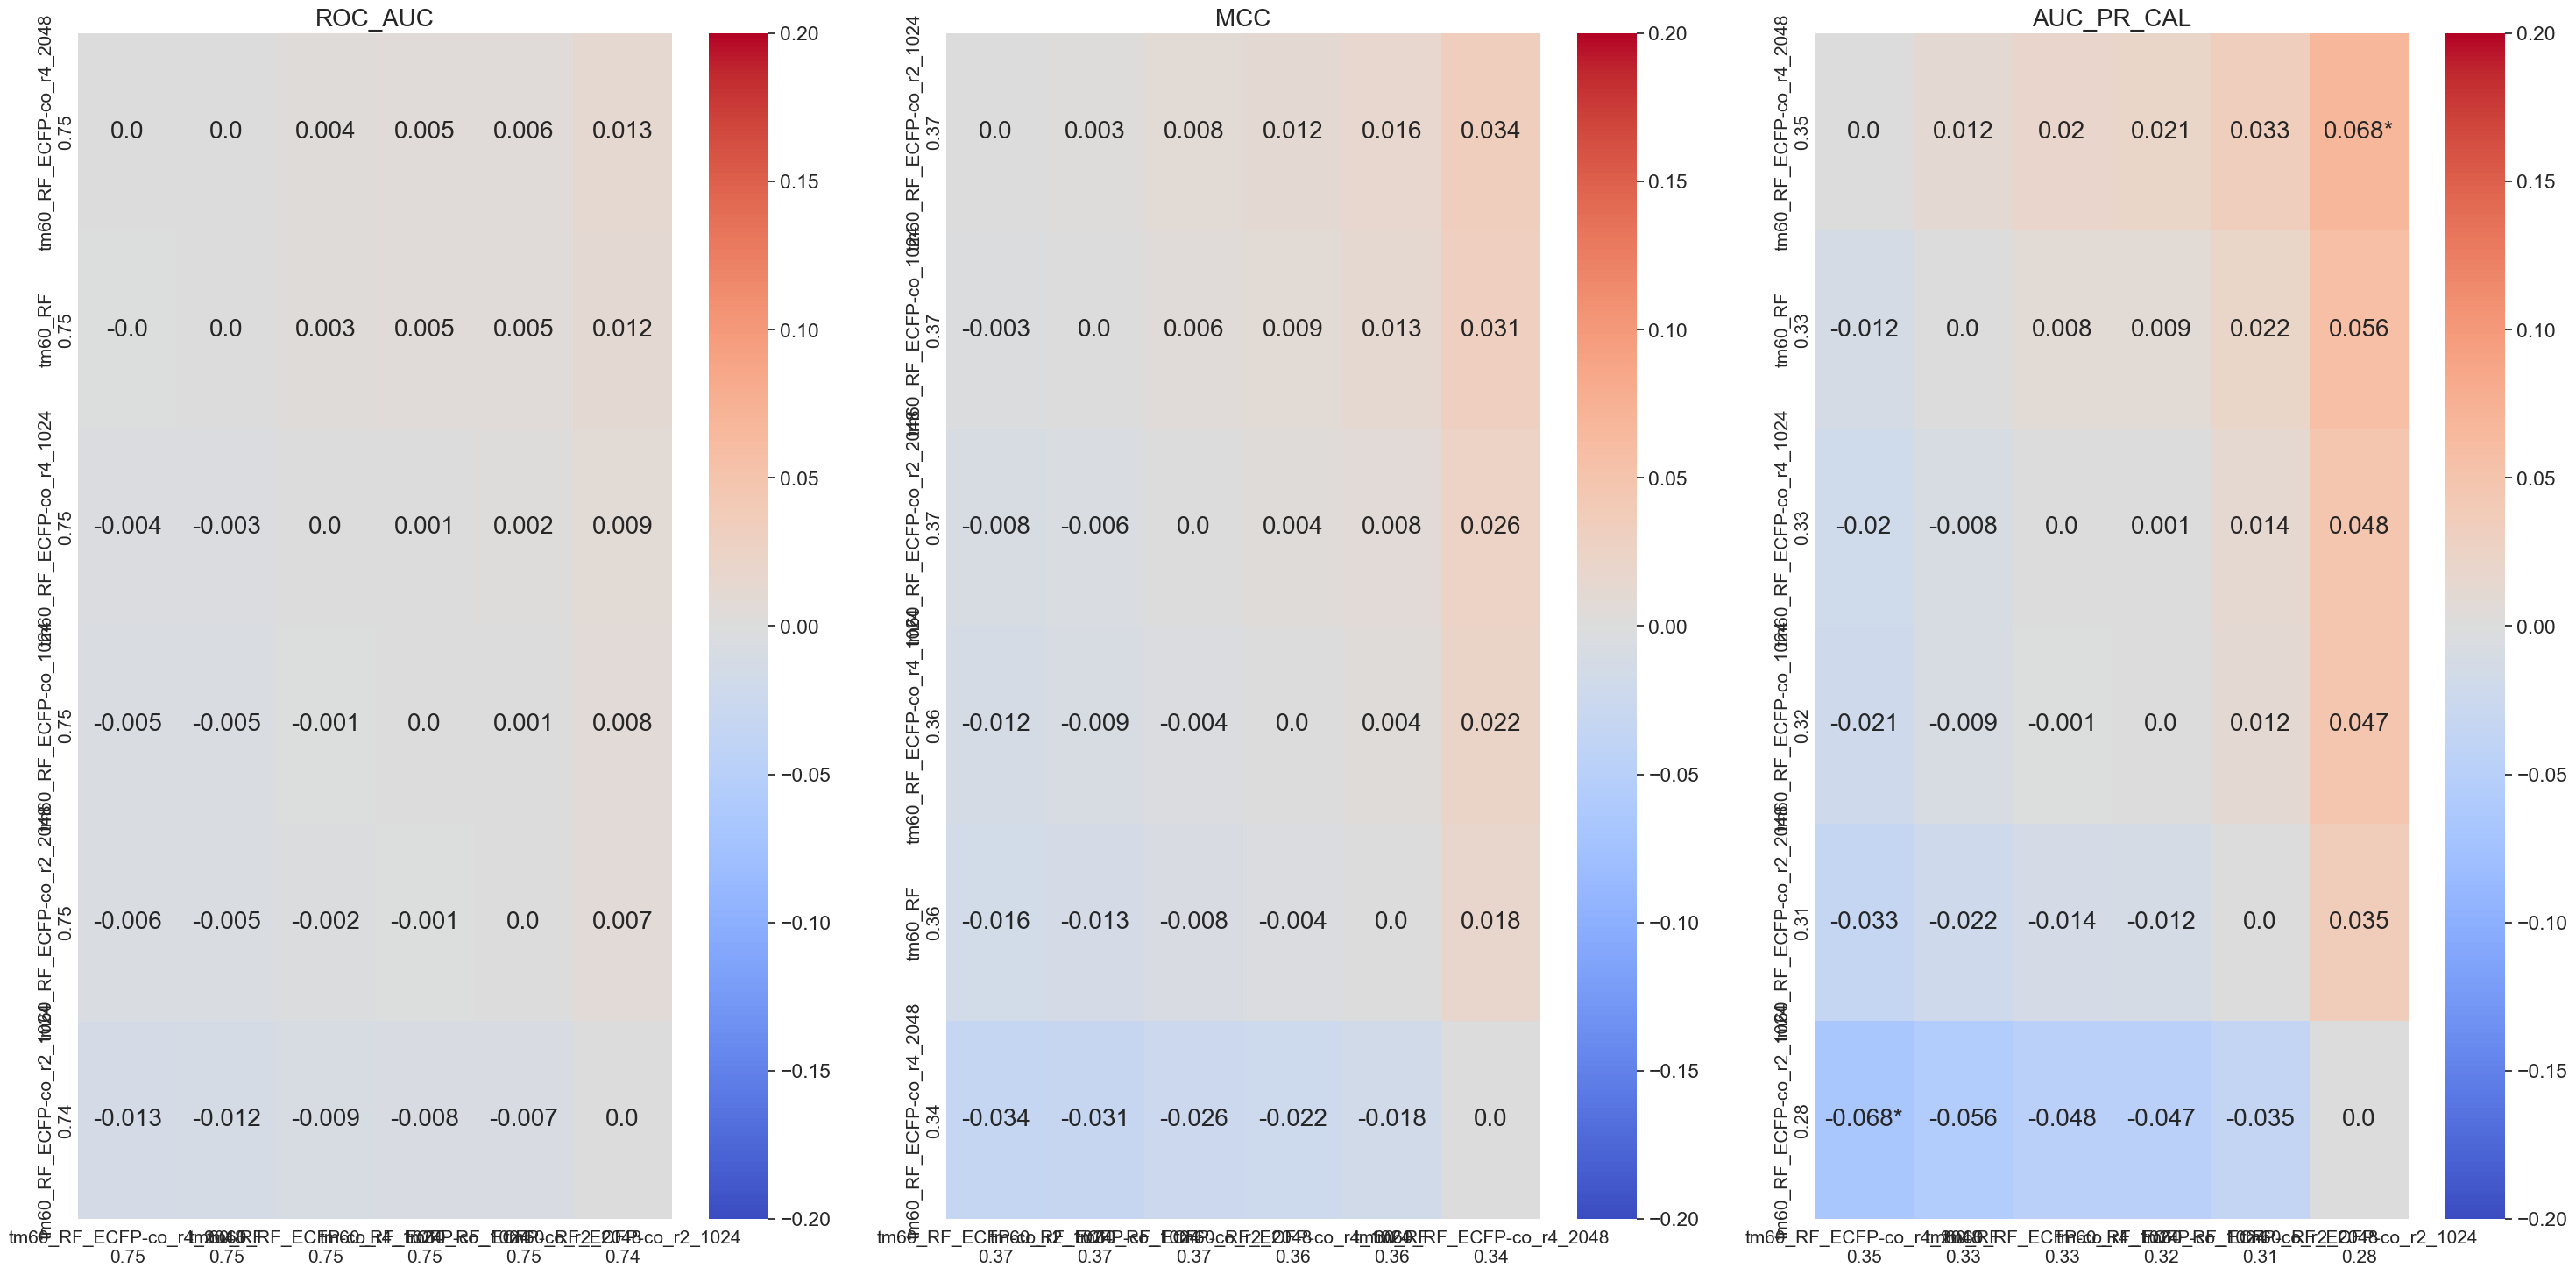

In [20]:
import importlib
import model_comparison

importlib.reload(model_comparison)

effect_dict = {'roc_auc':.1, 'mcc':.1, 'auc_pr_cal':.1}
direction_dict = {'roc_auc':'maximize', 'mcc':'maximize', 'auc_pr_cal':'maximize'}    

model_comparison.make_mcs_plot_grid(tm60_mods_df, metric_list, group_col="method", effect_dict=effect_dict, direction_dict=direction_dict,
                   figsize=(30, 15), cell_text_size=20, axis_text_size=15, title_text_size=20, show_diff=True, sort_axes=True)

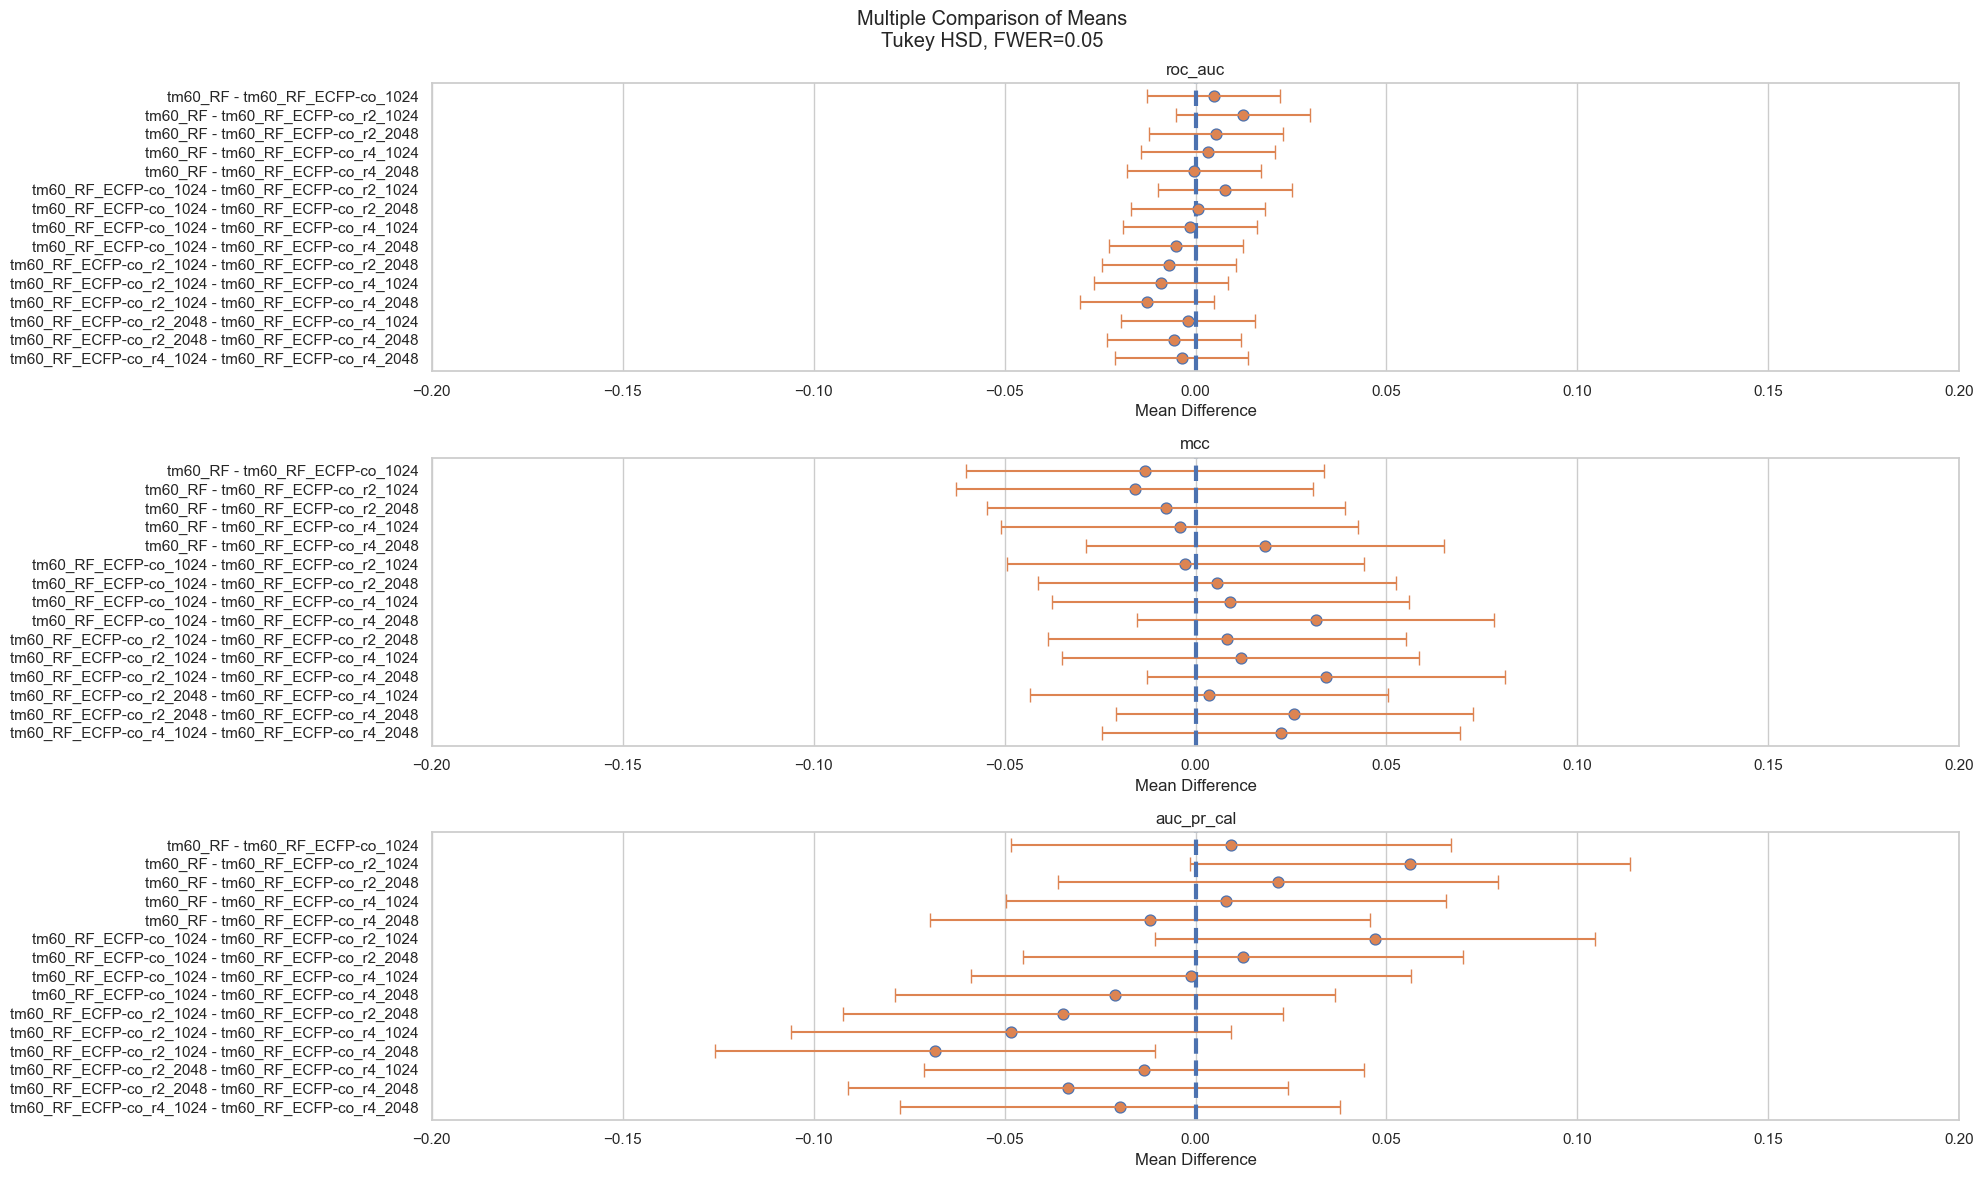

In [22]:
model_comparison.make_ci_plot_grid(tm60_mods_df, metric_list, "method")